In [2]:
import pandas as pd
import random
import numpy as np

# 01. Gerando os dados

In [3]:
# Para esse exercício, quero criar um dataset artificial de duas features com
# três clusters bem definidos MAS NÃO-CONVEXOS, para que eu possa observar o
# comportamento do DBSCAN e depois comparar com K-Means

df = pd.DataFrame(columns=["feat1", "feat2"])

# Cluster 1: Forma de lua (semicírculo)
n_samples_cluster = 100
for i in range(n_samples_cluster):
    angle = random.uniform(0, np.pi)
    radius = random.gauss(15, 2)
    x = 20 + radius * np.cos(angle)
    y = 20 + radius * np.sin(angle)
    df.loc[len(df)] = [x, y]

# Cluster 2: Forma de anel (círculo)
for i in range(n_samples_cluster):
    angle = random.uniform(0, 2 * np.pi)
    radius = random.gauss(30, 2)
    x = 60 + radius * np.cos(angle)
    y = 20 + radius * np.sin(angle)
    df.loc[len(df)] = [x, y]

# Cluster 3: Forma de espiral
for i in range(n_samples_cluster):
    t = random.uniform(0, 4 * np.pi)
    radius = 5 + (t / (4 * np.pi)) * 10
    x = 40 + radius * np.cos(t)
    y = 60 + radius * np.sin(t)
    df.loc[len(df)] = [x, y]

In [4]:
# Para este exercício, quero supersimplificar o problema e usar apenas duas features
# para que possa observar o comportamento do algoritmo com um plot
variables = [
    "feat1",
    "feat2"
]

df_x = df[variables]
X = df_x.values

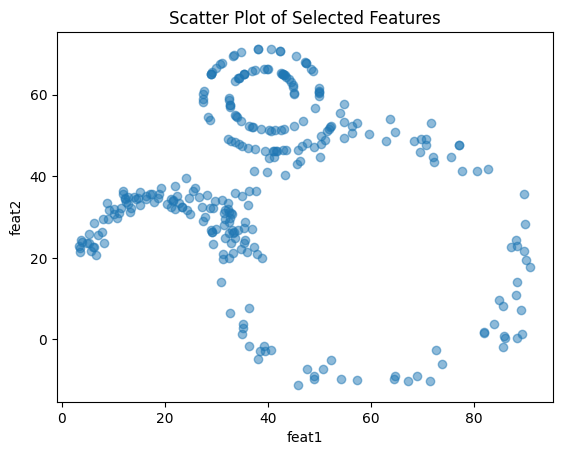

In [25]:
# Scatter plot das features selecionadas
import matplotlib.pyplot as plt

plt.scatter(df_x['feat1'], df_x['feat2'], alpha=0.5)
plt.xlabel('feat1')
plt.ylabel('feat2')
plt.title('Scatter Plot of Selected Features')
plt.show()

In [12]:
df.head()

,feat1,feat2
0,18.707230,34.572102
1,37.851459,20.909209
2,12.347976,34.510201
3,26.636531,35.012815
4,8.851282,33.413793


# 02. Construção do Modelo

In [ ]:
# Função para encontrar vizinhos dentro de eps
def get_neighbors(df, index, eps):
    point = df.loc[index, ["feat1", "feat2"]].values
    distances = np.sqrt((df[["feat1", "feat2"]].values - point) ** 2).sum(axis=1)
    return df[distances <= eps].index.tolist()

# Função para expandir cluster recursivamente
def expand_cluster(df, index, cluster_id, eps, min_samples, visited_set):
    neighbors = get_neighbors(df, index, eps)
    
    # Se não é um core point, não expande
    if len(neighbors) < min_samples:
        return
    
    # Adicionar ao cluster
    df.loc[index, "cluster"] = cluster_id
    df.loc[index, "visited"] = True
    
    # Expandir para os vizinhos
    for neighbor_idx in neighbors:
        if df.loc[neighbor_idx, "visited"]:
            continue
        
        df.loc[neighbor_idx, "visited"] = True
        neighbor_neighbors = get_neighbors(df, neighbor_idx, eps)
        
        # Se é um core point, expandir recursivamente
        if len(neighbor_neighbors) >= min_samples:
            expand_cluster(df, neighbor_idx, cluster_id, eps, min_samples, visited_set)
        
        # Se não é core, ainda adiciona como border point
        if np.isnan(df.loc[neighbor_idx, "cluster"]):
            df.loc[neighbor_idx, "cluster"] = cluster_id


In [144]:
eps = 5  # Distância máxima entre dois pontos para que sejam considerados vizinhos
min_samples = 3  # Número mínimo de pontos para formar um cluster

In [145]:
# Inicializar colunas
df["cluster"] = np.nan
df["visited"] = False
pontos_avaliados = list()

# Executar DBSCAN
cluster_id = 1
for idx in df.index:
    if not df.loc[idx, "visited"]:
        df.loc[idx, "visited"] = True
        neighbors = get_neighbors(df, idx, eps)
        
        # Se é core point, inicia novo cluster
        if len(neighbors) >= min_samples:
            expand_cluster(df, idx, cluster_id, eps, min_samples, set())
            cluster_id += 1


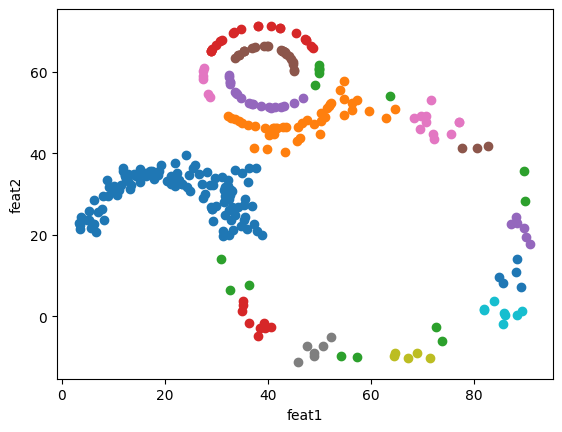

In [146]:
# Scatter plot das features selecionadas
import matplotlib.pyplot as plt

df["cluster"] = df["cluster"].fillna(-1)

for cluster in df["cluster"].unique():
    cluster_points = df[df['cluster'] == cluster]
    plt.scatter(cluster_points['feat1'], cluster_points['feat2'], label=f'Cluster {i}')
plt.xlabel('feat1')
plt.ylabel('feat2')
plt.show()